In [1]:
!pip uninstall -y transformers sentence-transformers

!pip install transformers==4.41.2
!pip install sentence-transformers==2.7.0
!pip install faiss-cpu

Found existing installation: transformers 4.41.2
Uninstalling transformers-4.41.2:
  Successfully uninstalled transformers-4.41.2
Found existing installation: sentence-transformers 5.4.1
Uninstalling sentence-transformers-5.4.1:
  Successfully uninstalled sentence-transformers-5.4.1
  Using cached transformers-4.41.2-py3-none-any.whl.metadata (43 kB)
Using cached transformers-4.41.2-py3-none-any.whl (9.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.5/171.5 kB 7.3 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import faiss
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
df = pd.read_csv("/content/shakespeare_plays.csv")

df.head()

,Unnamed: 0,play_name,genre,character,act,scene,sentence,text,sex
0,0,All's Well That Ends Well,Comedy,Countess,1,1,1,"In delivering my son from me, I bury a second ...",female
1,1,All's Well That Ends Well,Comedy,Bertram,1,1,2,"And I in going, madam, weep o'er my father's d...",male
2,2,All's Well That Ends Well,Comedy,Bertram,1,1,3,"anew: but I must attend his majesty's command, to",male
3,3,All's Well That Ends Well,Comedy,Bertram,1,1,4,"whom I am now in ward, evermore in subjection.",male
4,4,All's Well That Ends Well,Comedy,Lafeu,1,1,5,"You shall find of the king a husband, madam; you,",male


In [4]:
plays = ["Hamlet", "Macbeth", "Romeo and Juliet"]

df = df[df["play_name"].isin(plays)]

print(df.shape)

(9487, 9)


In [5]:
# Remove Missing Values
df = df.dropna(subset=["text", "character"])

df = df.reset_index(drop=True)

In [6]:
# cleaned dataset
df = df.dropna(subset=["text", "character"])

df = df.reset_index(drop=True)

print(df.isnull().sum())

Unnamed: 0    0
play_name     0
genre         0
character     0
act           0
scene         0
sentence      0
text          0
sex           0
dtype: int64


Create Retrieval Chunks

In [7]:
chunks = []

for _, row in df.iterrows():

    chunk = {
        "play": row["play_name"],
        "act": row["act"],
        "scene": row["scene"],
        "speaker": row["character"],
        "text": row["text"]
    }

    chunks.append(chunk)

print("Total Chunks:", len(chunks))

Total Chunks: 9487


Create Text List

In [8]:
texts = [chunk["text"] for chunk in chunks]

print("Total Text Chunks:", len(texts))

print("\nSample Text Chunk:\n")
print(texts[0])

Total Text Chunks: 9487

Sample Text Chunk:

Who's there?


Load Embedding Model

In [9]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Embedding Model Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Embedding Model Loaded Successfully


In [10]:
# Generate Embeddings

embeddings = embedding_model.encode(
    texts,
    show_progress_bar=True
)

print("Embeddings Generated Successfully")

print("\nEmbedding Shape:")
print(embeddings.shape)


Batches:   0%|          | 0/297 [00:00<?, ?it/s]

Embeddings Generated Successfully

Embedding Shape:
(9487, 384)


Show Sample Embedding Values

In [11]:
print("First Embedding Vector:\n")

print(embeddings[0][:20])

First Embedding Vector:

[-0.12365959 -0.03088307  0.01096812  0.02923218  0.03501134  0.01624053
  0.0443363  -0.05004353  0.03876568  0.0098264  -0.00085272 -0.13598998
 -0.0363018   0.00074947 -0.088981   -0.0656951  -0.01138186 -0.06969427
  0.01766374 -0.09139235]


Create FAISS Index

In [12]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(np.array(embeddings))

print("FAISS Index Created Successfully")

print("\nNumber of Stored Vectors:")
print(index.ntotal)

FAISS Index Created Successfully

Number of Stored Vectors:
9487


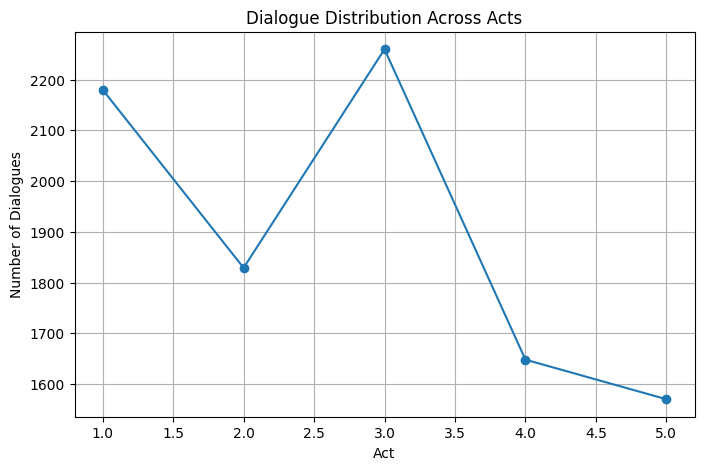

In [22]:
act_counts = df["act"].value_counts().sort_index()

plt.figure(figsize=(8,5))

act_counts.plot(
    kind="line",
    marker="o"
)

plt.title("Dialogue Distribution Across Acts")

plt.xlabel("Act")

plt.ylabel("Number of Dialogues")

plt.grid(True)

plt.show()

Test Retrieval BEFORE LLM

In [13]:
query = "Who killed Macbeth?"

query_embedding = embedding_model.encode([query])

distances, indices = index.search(
    np.array(query_embedding),
    3
)

print("Retrieved Results:\n")

for i, idx in enumerate(indices[0]):

    print(f"Result {i+1}")
    print("-" * 50)

    print("Play:", chunks[idx]["play"])
    print("Act:", chunks[idx]["act"])
    print("Scene:", chunks[idx]["scene"])
    print("Speaker:", chunks[idx]["speaker"])

    print("\nText:")
    print(chunks[idx]["text"])

    print("\nDistance Score:")
    print(distances[0][i])

    print("\n")

Retrieved Results:

Result 1
--------------------------------------------------
Play: Macbeth
Act: 3
Scene: 3
Speaker: Third Murderer

Text:
Macbeth.

Distance Score:
0.38884157


Result 2
--------------------------------------------------
Play: Macbeth
Act: 2
Scene: 4
Speaker: Macduff

Text:
Those that Macbeth hath slain.

Distance Score:
0.46405423


Result 3
--------------------------------------------------
Play: Macbeth
Act: 3
Scene: 6
Speaker: Lennox

Text:
Was pitied of Macbeth: marry, he was dead:

Distance Score:
0.5000379




In [14]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

generator = pipeline(
    "text2text-generation",
    model=model,
    tokenizer=tokenizer
)

print("LLM Loaded Successfully")

LLM Loaded Successfully


Create Retrieval Function

In [15]:
def retrieve(query, k=3):

    query_embedding = embedding_model.encode([query])

    distances, indices = index.search(
        np.array(query_embedding),
        k
    )

    results = []

    for idx in indices[0]:
        results.append(chunks[idx])

    return results

In [16]:
# Create Final RAG Function
def ask_question(query):

    retrieved_docs = retrieve(query)

    context = ""

    for doc in retrieved_docs:

        context += f"""
Play: {doc['play']}
Act: {doc['act']}
Scene: {doc['scene']}
Speaker: {doc['speaker']}

Text:
{doc['text']}
"""

    print("=" * 60)
    print("RETRIEVED CONTEXT")
    print("=" * 60)

    print(context)

    prompt = f"""
Answer the question using the context below.

Context:
{context}

Question:
{query}

Answer:
"""

    response = generator(prompt)

    answer = response[0]['generated_text']

    print("\n" + "=" * 60)
    print("FINAL ANSWER")
    print("=" * 60)

    print(answer)

Visualisations

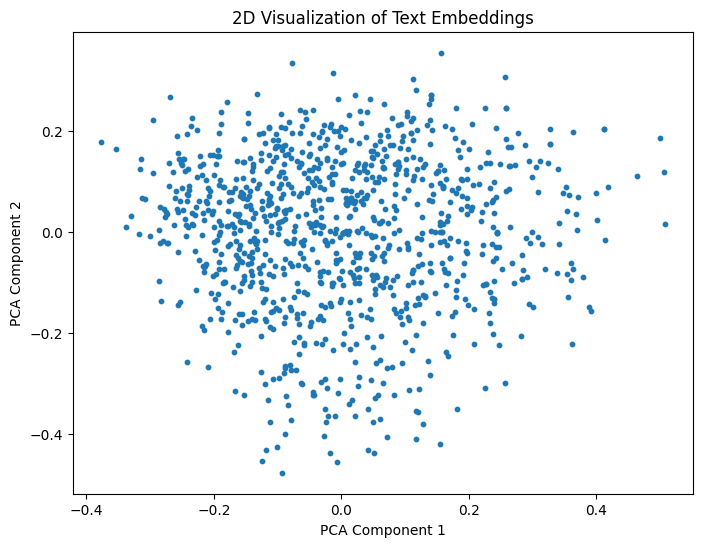

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(
    embeddings[:1000]
)

plt.figure(figsize=(8,6))

plt.scatter(
    reduced_embeddings[:,0],
    reduced_embeddings[:,1],
    s=10
)

plt.title("2D Visualization of Text Embeddings")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.show()

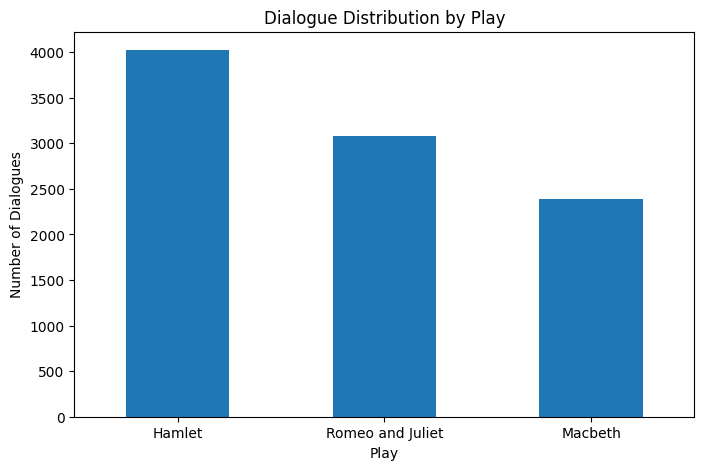

In [23]:
play_counts = df["play_name"].value_counts()

plt.figure(figsize=(8,5))

play_counts.plot(kind="bar")

plt.title("Dialogue Distribution by Play")

plt.xlabel("Play")

plt.ylabel("Number of Dialogues")

plt.xticks(rotation=0)

plt.show()

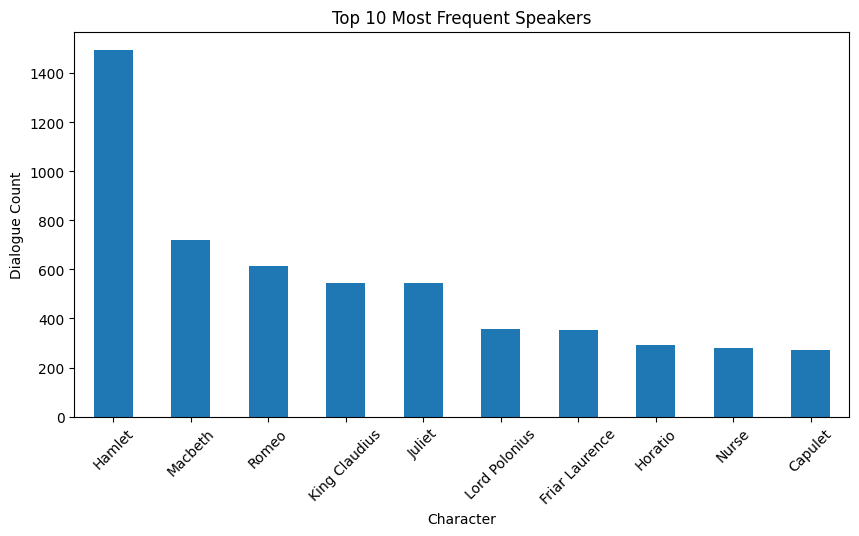

In [25]:
top_characters = df["character"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_characters.plot(kind="bar")

plt.title("Top 10 Most Frequent Speakers")

plt.xlabel("Character")

plt.ylabel("Dialogue Count")

plt.xticks(rotation=45)

plt.show()

Final Testing

In [19]:
# Test case 1

ask_question("Who killed Macbeth?")

RETRIEVED CONTEXT

Play: Macbeth
Act: 3
Scene: 3
Speaker: Third Murderer

Text:
Macbeth.

Play: Macbeth
Act: 2
Scene: 4
Speaker: Macduff

Text:
Those that Macbeth hath slain.

Play: Macbeth
Act: 3
Scene: 6
Speaker: Lennox

Text:
Was pitied of Macbeth: marry, he was dead:


FINAL ANSWER
Lennox


In [20]:
# Test Case 2

ask_question("Why is Hamlet sad?")

RETRIEVED CONTEXT

Play: Hamlet
Act: 1
Scene: 5
Speaker: Hamlet

Text:
And what so poor a man as Hamlet is

Play: Hamlet
Act: 3
Scene: 4
Speaker: Queen Gertrude

Text:
Why, how now, Hamlet!

Play: Hamlet
Act: 2
Scene: 2
Speaker: Lord Polonius

Text:
How does my good Lord Hamlet?


FINAL ANSWER
He is poor.
